# Recursion on Graphs — How it works, step by step

Every recursive graph method — no matter how complex — is a variation of
**one core pattern**: Depth-First Search (DFS).

| Section | Method | Recursion type |
|---|---|---|
| 1 | *abstract DFS skeleton* | the universal template |
| 2 | `Graph.is_connected()` | **spreading** — mark neighbours |
| 3 | `Graph.connected_components()` | spreading over many starts |
| 4 | `DirectedGraph.has_cycle()` | **state tracking** — three colours |
| 5 | `Graph.all_paths()` / `DAG.all_paths()` | **backtracking** — explore & undo |
| 6 | `Tree.height()` | **bottom-up computation** — return values up the stack |
| 7 | `Tree.pre_order()` vs `post_order()` | when you *process* matters |
| 8 | `DAG.descendants()` / `ancestors()` | spreading on directed graph |

---

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
from graphs import Graph, DAG, DirectedGraph, Tree, format_solutions

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ── Drawing utilities ─────────────────────────────────────────────────

def _circ_pos(graph):
    '''Circular layout, one circle per connected component.'''
    if hasattr(graph, 'connected_components'):
        components = graph.connected_components()
    else:
        components = [sorted(graph.nodes())]
    pos, cx = {}, 0.0
    for comp in components:
        n = len(comp)
        r = max(1.0, n * 0.45)
        for i, node in enumerate(sorted(comp)):
            angle = 2 * math.pi * i / n - math.pi / 2
            pos[node] = (cx + (r * math.cos(angle) if n > 1 else 0),
                         r * math.sin(angle) if n > 1 else 0.0)
        cx += 2 * r + 1.5
    xs = [p[0] for p in pos.values()]
    mid = (min(xs) + max(xs)) / 2
    return {n: (x - mid, y) for n, (x, y) in pos.items()}

def _layer_pos(dag):
    '''Layered layout for DAGs; falls back to circular for DirectedGraph.'''
    if not hasattr(dag, 'topological_sort'):
        return _circ_pos(dag)
    topo = dag.topological_sort()
    layer = {n: 0 for n in dag.nodes()}
    for n in topo:
        for c in dag.children(n):
            layer[c] = max(layer[c], layer[n] + 1)
    buckets = {}
    for n, l in layer.items():
        buckets.setdefault(l, []).append(n)
    for l in buckets: buckets[l].sort()
    pos = {}
    for l, ns in buckets.items():
        for i, n in enumerate(ns):
            pos[n] = (l * 3.0, -(i - (len(ns)-1)/2.0) * 2.0)
    return pos

def _draw(pos, nodes, edges, is_directed,
          hi_nodes=None, hi_edges=None, title='', legend=None, figsize=None):
    hi_nodes = set(hi_nodes or [])
    hi_he    = set()
    for e in (hi_edges or []):
        hi_he.add(tuple(e) if is_directed else tuple(sorted(e)))

    xs  = [p[0] for p in pos.values()]
    ys  = [p[1] for p in pos.values()]
    pad = 1.0
    fw  = max(6, (max(xs)-min(xs)+2*pad) * 1.3)
    fh  = max(5, (max(ys)-min(ys)+2*pad) * 1.8)
    if figsize: fw, fh = figsize
    fig, ax = plt.subplots(figsize=(fw, fh))
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.axis('off'); ax.set_aspect('equal')
    NODE_R = 0.50

    drawn = set()
    for a, b in edges:
        key = (a, b) if is_directed else tuple(sorted([a, b]))
        if not is_directed and key in drawn: continue
        drawn.add(key)
        x0, y0 = pos[a]; x1, y1 = pos[b]
        dx, dy = x1-x0, y1-y0
        length = (dx**2+dy**2)**0.5
        if length < 1e-9: continue
        ux, uy = dx/length, dy/length
        is_hi = key in hi_he
        clr   = '#D94F4F' if is_hi else '#BBBBBB'
        lw    = 2.8 if is_hi else 1.5
        if is_directed:
            ax.annotate('', xy=(x1-ux*NODE_R, y1-uy*NODE_R),
                        xytext=(x0+ux*NODE_R, y0+uy*NODE_R),
                        arrowprops=dict(arrowstyle='-|>', color=clr,
                                        lw=lw, mutation_scale=14))
        else:
            ax.plot([x0+ux*NODE_R, x1-ux*NODE_R],
                    [y0+uy*NODE_R, y1-uy*NODE_R], color=clr, lw=lw, zorder=1)

    for n in nodes:
        x, y = pos[n]
        fc = '#D94F4F' if n in hi_nodes else '#3A86D4'
        ax.add_patch(plt.Circle((x, y), NODE_R, color=fc, ec='white', lw=2, zorder=3))
        ax.text(x, y, n, ha='center', va='center',
                fontsize=9, color='white', fontweight='bold', zorder=4)

    if legend:
        ax.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in legend],
                  loc='lower right', fontsize=9, framealpha=0.85)
    ax.set_xlim(min(xs)-pad, max(xs)+pad)
    ax.set_ylim(min(ys)-pad, max(ys)+pad)
    plt.tight_layout(); plt.show()

def show_graph(g, title='', hi_nodes=None, hi_edges=None, legend=None):
    pos = _circ_pos(g)
    _draw(pos, g.nodes(), g.edges(), False,
          hi_nodes, hi_edges, title, legend)

def show_dag(g, title='', hi_nodes=None, hi_edges=None, legend=None):
    pos = _layer_pos(g)
    _draw(pos, g.nodes(), g.edges(), True,
          hi_nodes, hi_edges, title, legend)

print('Setup complete.')

Setup complete.


---
## The one pattern behind every recursive graph algorithm

All DFS-based methods in `graphs.py` share the **same skeleton**:

```python
def dfs(node, visited, ...):
    visited.add(node)           # 1. Mark: "I've been here"
    <do something with node>    # 2. Act: depends on the problem
    for neighbour in adj[node]:
        if neighbour not in visited:
            dfs(neighbour, visited, ...)  # 3. Recurse into unvisited neighbours
```

The three parts are always present. **Only step 2 changes** between methods:

| Method | What step 2 does |
|---|---|
| `is_connected()` | nothing (just mark) |
| `connected_components()` | append node to current component list |
| `descendants()` | add node to result set |
| `all_paths()` | append to current path; after recursing, **pop** (backtrack) |
| `height()` | after recursing children, return `1 + max(child results)` |
| `pre_order()` | append node BEFORE recursing into children |
| `post_order()` | append node AFTER recursing into children |

Let's see each one in action.

In [2]:
# ── The abstract DFS, made completely visible ─────────────────────────
# This is the EXACT pattern used in is_connected(), descendants(), etc.

def traced_dfs(adj, start):
    '''DFS from start — prints every visit and skip'''
    visited = set()

    def dfs(u, depth=0):
        indent = '  ' * depth
        visited.add(u)
        print(f'{indent}visit {u!r}  ->  visited so far = {sorted(visited)}')
        for v in sorted(adj.get(u, [])):
            if v not in visited:
                print(f'{indent}  edge {u!r}--{v!r}: follow')
                dfs(v, depth + 1)
            else:
                print(f'{indent}  edge {u!r}--{v!r}: skip ({v!r} already visited)')

    dfs(start)
    return visited

# graph: A-B-C-D with a cross edge A-C
adj = {'A': ['B','C'], 'B': ['A','D'], 'C': ['A','D'], 'D': ['B','C']}
print('Graph: A-B, A-C, B-D, C-D  (a square with diagonals)')
print('Starting DFS from A:')
print()
result = traced_dfs(adj, 'A')
print()
print('All nodes visited?', result == set(adj))

Graph: A-B, A-C, B-D, C-D  (a square with diagonals)
Starting DFS from A:

visit 'A'  ->  visited so far = ['A']
  edge 'A'--'B': follow
  visit 'B'  ->  visited so far = ['A', 'B']
    edge 'B'--'A': skip ('A' already visited)
    edge 'B'--'D': follow
    visit 'D'  ->  visited so far = ['A', 'B', 'D']
      edge 'D'--'B': skip ('B' already visited)
      edge 'D'--'C': follow
      visit 'C'  ->  visited so far = ['A', 'B', 'C', 'D']
        edge 'C'--'A': skip ('A' already visited)
        edge 'C'--'D': skip ('D' already visited)
  edge 'A'--'C': skip ('C' already visited)

All nodes visited? True


---
## Pattern 1 — DFS Spreading: `is_connected()`

The simplest useful DFS: just mark nodes.  
After DFS finishes, *every reachable node is marked*.  
If all nodes are marked → the graph is connected.

```python
def is_connected(self):
    visited = set()
    def dfs(u):
        visited.add(u)          # mark
        for v in adj[u]:
            if v not in visited:
                dfs(v)          # spread
    dfs(any_start_node)
    return len(visited) == len(all_nodes)
```

The call stack grows as DFS goes deeper and shrinks as it returns —  
but the visited set only grows, never shrinks.


[Graph.__init__] Internal data structure
  _adj  =  adjacency list
  Maps every node to the list of its direct neighbours.
  Because the graph is UNDIRECTED, every edge A-B is stored
  in BOTH directions: adj[A] contains B  AND  adj[B] contains A.

  _adj['A'] = ['B']
  _adj['B'] = ['A', 'C']
  _adj['C'] = ['B', 'D']
  _adj['D'] = ['C', 'E']
  _adj['E'] = ['D']


[Graph.is_connected]
  Strategy: DFS from any one node.
  If all nodes are visited -> the graph is one piece (connected).
  Start DFS from 'A':
    visit 'A'
    visit 'B'
    visit 'C'
    visit 'D'
    visit 'E'
  All 5 nodes reached -> connected: True
is_connected(): True

[Graph.connected_components]
  Strategy: repeat DFS from each unvisited node.
  Each DFS discovers one complete island (component).
  Component #1: ['A', 'B', 'C', 'D', 'E']
  Total: 1 component(s)


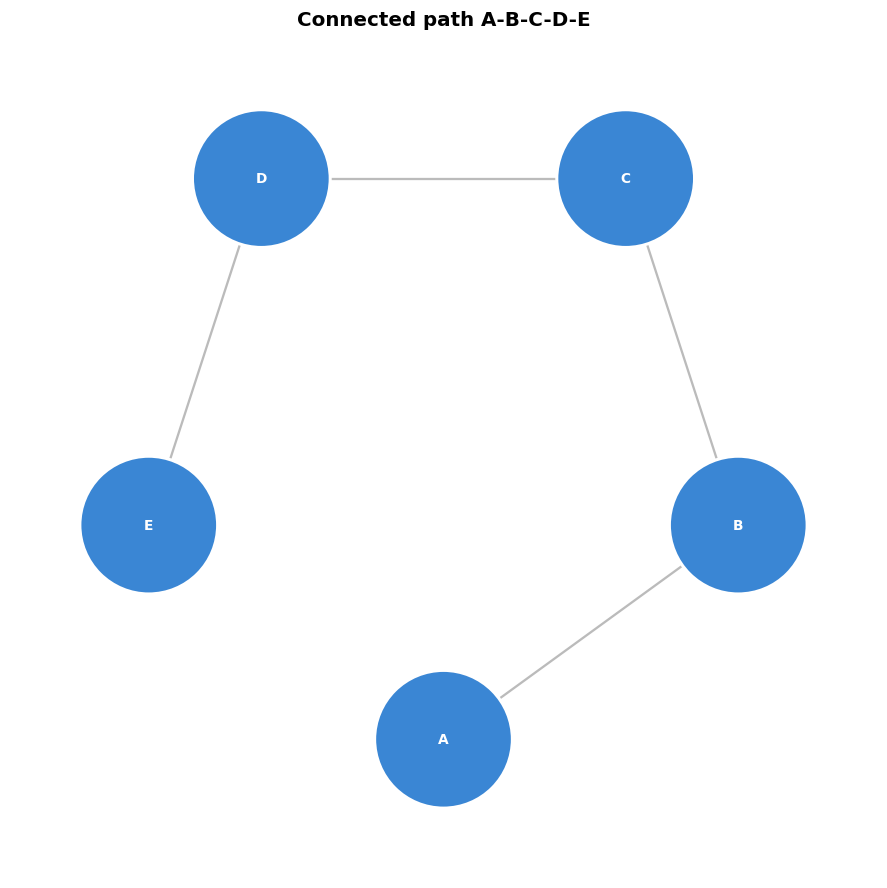

In [3]:
# ── is_connected() with debug ─────────────────────────────────────────
g_connected = Graph(edges=[('A','B'),('B','C'),('C','D'),('D','E')], debug=True)
print('is_connected():', g_connected.is_connected())

show_graph(g_connected, title='Connected path A-B-C-D-E')


[Graph.__init__] Internal data structure
  _adj  =  adjacency list
  Maps every node to the list of its direct neighbours.
  Because the graph is UNDIRECTED, every edge A-B is stored
  in BOTH directions: adj[A] contains B  AND  adj[B] contains A.

  _adj['A'] = ['B']
  _adj['B'] = ['A', 'C']
  _adj['C'] = ['B']
  _adj['X'] = ['Y']
  _adj['Y'] = ['X', 'Z']
  _adj['Z'] = ['Y']


[Graph.is_connected]
  Strategy: DFS from any one node.
  If all nodes are visited -> the graph is one piece (connected).
  Start DFS from 'A':
    visit 'A'
    visit 'B'
    visit 'C'
  Only 3/6 nodes reached.
  Unreachable: ['X', 'Y', 'Z'] -> connected: False
is_connected(): False

[Graph.connected_components]
  Strategy: repeat DFS from each unvisited node.
  Each DFS discovers one complete island (component).
  Component #1: ['A', 'B', 'C']
  Component #2: ['X', 'Y', 'Z']
  Total: 2 component(s)
components    : [['A', 'B', 'C'], ['X', 'Y', 'Z']]

[Graph.connected_components]
  Strategy: repeat DFS from eac

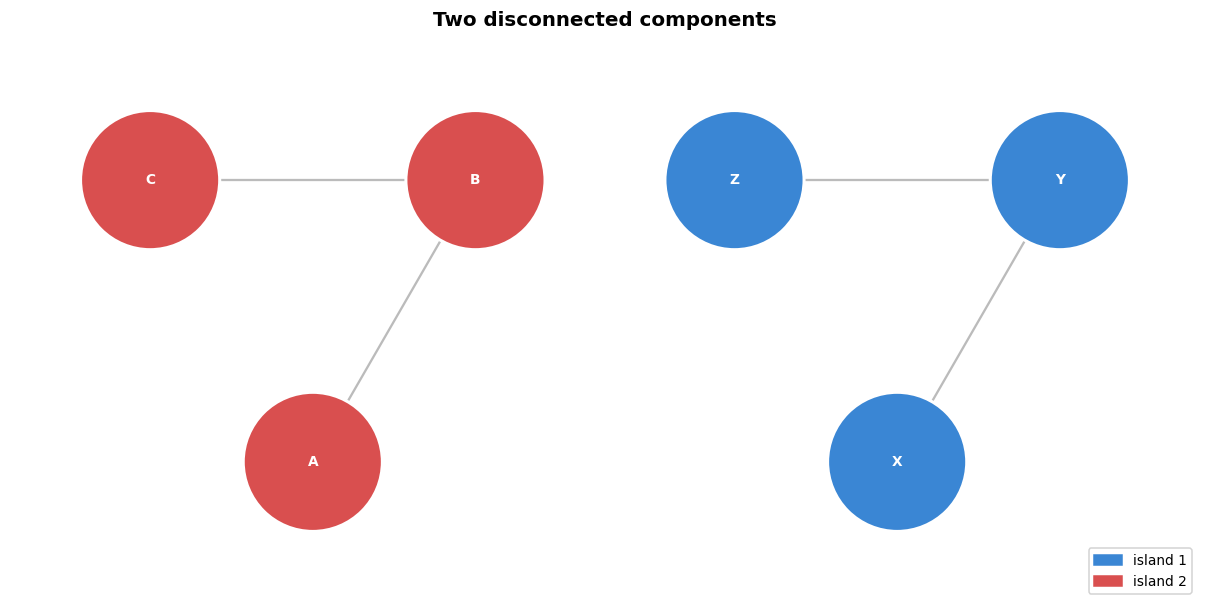

In [4]:
# ── What changes when there are two islands? ──────────────────────────
g_split = Graph(edges=[('A','B'),('B','C'),('X','Y'),('Y','Z')], debug=True)
print('is_connected():', g_split.is_connected())
print('components    :', g_split.connected_components())

show_graph(g_split,
           title='Two disconnected components',
           hi_nodes=['A','B','C'],
           legend=[('#3A86D4','island 1'), ('#D94F4F','island 2')])

---
## Pattern 2 — DFS with state: `has_cycle()` (three colours)

Now step 2 does more: it track **how** a node was reached.

```
WHITE = not yet visited
GRAY  = on the current recursion stack (being explored RIGHT NOW)
BLACK = fully explored
```

The insight: if DFS reaches a **GRAY** node, we've looped back to  
a node we're *currently* exploring — that's a directed cycle!

```python
def has_cycle(self):
    color = {n: WHITE for n in nodes}
    def dfs(u):
        color[u] = GRAY          # "I'm exploring this right now"
        for v in forward_adj[u]:
            if color[v] == GRAY: return True   # loop back to active frame!
            if color[v] == WHITE and dfs(v): return True
        color[u] = BLACK         # "done, safe"
        return False
```

No cycle vs cycle — watch the colours change:

=== Acyclic graph A->B->C->D ===

[DirectedGraph.__init__] Internal data structures
  _forward_adj  maps each node to its CHILDREN
                (nodes this node has an arrow pointing TO)
  _reverse_adj  maps each node to its PARENTS
                (nodes that have an arrow pointing TO this node)
  Both dicts are kept in sync so parent lookups stay cheap.

  Node        children (_forward_adj)         parents (_reverse_adj)
  ------------------------------------------------------------------
  A           ['B']                           []
  B           ['C']                           ['A']
  C           ['D']                           ['B']
  D           []                              ['C']


[DirectedGraph.has_cycle]  Three-colour DFS
  WHITE  = not yet visited
  GRAY   = currently being explored (on the recursion stack RIGHT NOW)
  BLACK  = fully explored (no cycles found below this node)
  KEY: reaching a GRAY node = we looped back = DIRECTED CYCLE!

  Start DFS from 'A' (unvis

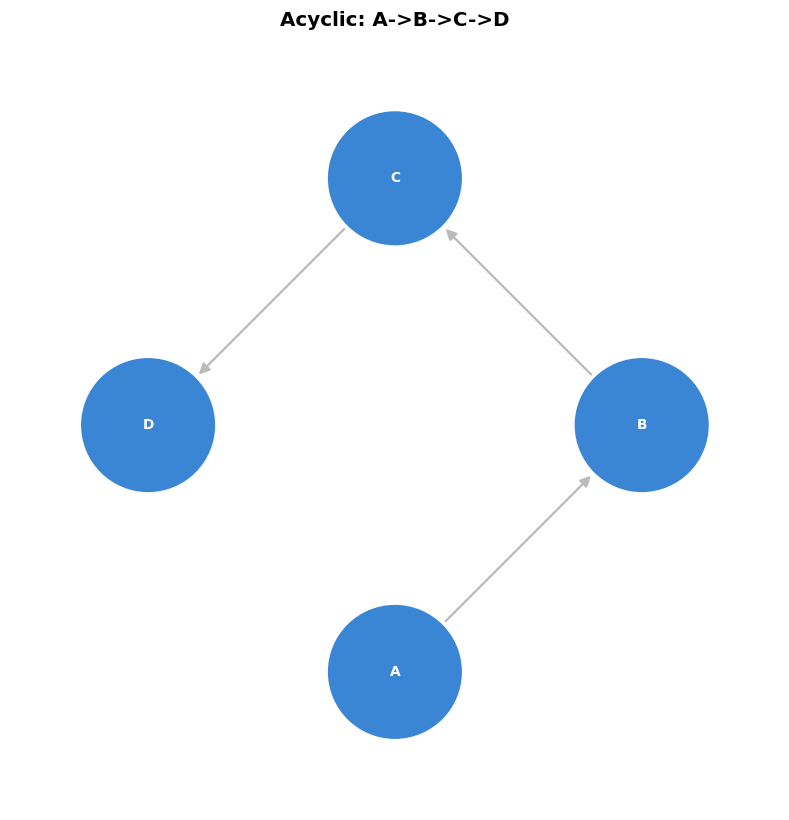

In [5]:
# ── Acyclic directed graph — three-colour DFS ─────────────────────────
print('=== Acyclic graph A->B->C->D ===')
dg_safe = DirectedGraph(edges=[('A','B'),('B','C'),('C','D')], debug=True)
print('has_cycle():', dg_safe.has_cycle())
show_dag(dg_safe, title='Acyclic: A->B->C->D')

=== Cyclic graph A->B->C->A ===

[DirectedGraph.__init__] Internal data structures
  _forward_adj  maps each node to its CHILDREN
                (nodes this node has an arrow pointing TO)
  _reverse_adj  maps each node to its PARENTS
                (nodes that have an arrow pointing TO this node)
  Both dicts are kept in sync so parent lookups stay cheap.

  Node        children (_forward_adj)         parents (_reverse_adj)
  ------------------------------------------------------------------
  A           ['B']                           ['C']
  B           ['C']                           ['A']
  C           ['A']                           ['B']


[DirectedGraph.has_cycle]  Three-colour DFS
  WHITE  = not yet visited
  GRAY   = currently being explored (on the recursion stack RIGHT NOW)
  BLACK  = fully explored (no cycles found below this node)
  KEY: reaching a GRAY node = we looped back = DIRECTED CYCLE!

  Start DFS from 'A' (unvisited)
  'A': WHITE -> GRAY  (start exploring)
    

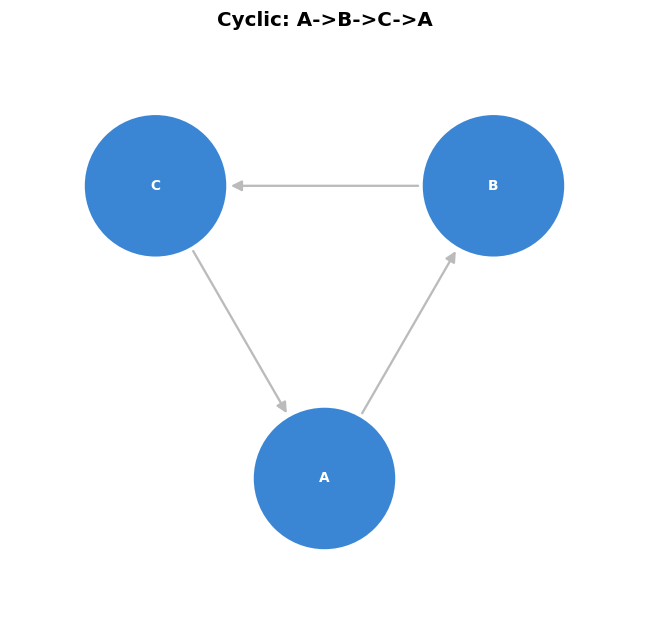

In [6]:
# ── Now introduce a back-edge C->A (creating a cycle) ─────────────────
print('=== Cyclic graph A->B->C->A ===')
dg_cycle = DirectedGraph(edges=[('A','B'),('B','C'),('C','A')], debug=True)
print('has_cycle():', dg_cycle.has_cycle())
show_dag(dg_cycle, title='Cyclic: A->B->C->A')

---
## Pattern 3 — DFS with backtracking: `all_paths()`

This is the most powerful pattern.  
Step 2 has TWO parts: **extend** the path going in, **undo** coming back.

```python
def all_paths(src, dst):
    result = []
    def dfs(u, path, on_path):
        if u == dst:
            result.append(list(path))   # found one!
            return
        for v in adj[u]:
            if v not in on_path:
                path.append(v)          # EXTEND — go forward
                on_path.add(v)
                dfs(v, path, on_path)
                path.pop()              # UNDO — come back
                on_path.remove(v)
    dfs(src, [src], {src})
```

The `pop()` / `remove()` calls are the **backtracking step**.  
They restore the state exactly as it was *before* that branch was tried.  
This lets the function try the next branch in a clean state.

Watch it happen:

In [7]:
# ── Traced all_paths: see every extend and backtrack ──────────────────
def traced_all_paths(adj, src, dst):
    '''Shows every path extension and backtrack step.'''
    found = []

    def dfs(u, path, on_path, depth=0):
        indent = '  ' * depth
        if u == dst:
            print(f'{indent}*** FOUND: {list(path)}')
            found.append(list(path))
            return
        for v in sorted(adj.get(u, [])):
            if v not in on_path:
                path.append(v); on_path.add(v)
                print(f'{indent}extend  path -> {list(path)}')
                dfs(v, path, on_path, depth + 1)
                path.pop(); on_path.remove(v)
                print(f'{indent}UNDO    path -> {list(path)}')

    dfs(src, [src], {src})
    return found

# Graph: A has two routes to D
adj = {'A': ['B','C'], 'B': ['D'], 'C': ['D'], 'D': []}
print('Graph: A->B->D and A->C->D')
print('Finding all paths A->D:')
print()
paths = traced_all_paths(adj, 'A', 'D')
print()
print('All paths found:', paths)

Graph: A->B->D and A->C->D
Finding all paths A->D:

extend  path -> ['A', 'B']
  extend  path -> ['A', 'B', 'D']
    *** FOUND: ['A', 'B', 'D']
  UNDO    path -> ['A', 'B']
UNDO    path -> ['A']
extend  path -> ['A', 'C']
  extend  path -> ['A', 'C', 'D']
    *** FOUND: ['A', 'C', 'D']
  UNDO    path -> ['A', 'C']
UNDO    path -> ['A']

All paths found: [['A', 'B', 'D'], ['A', 'C', 'D']]


DAG.all_paths A->D: [['A', 'B', 'D'], ['A', 'C', 'D']]


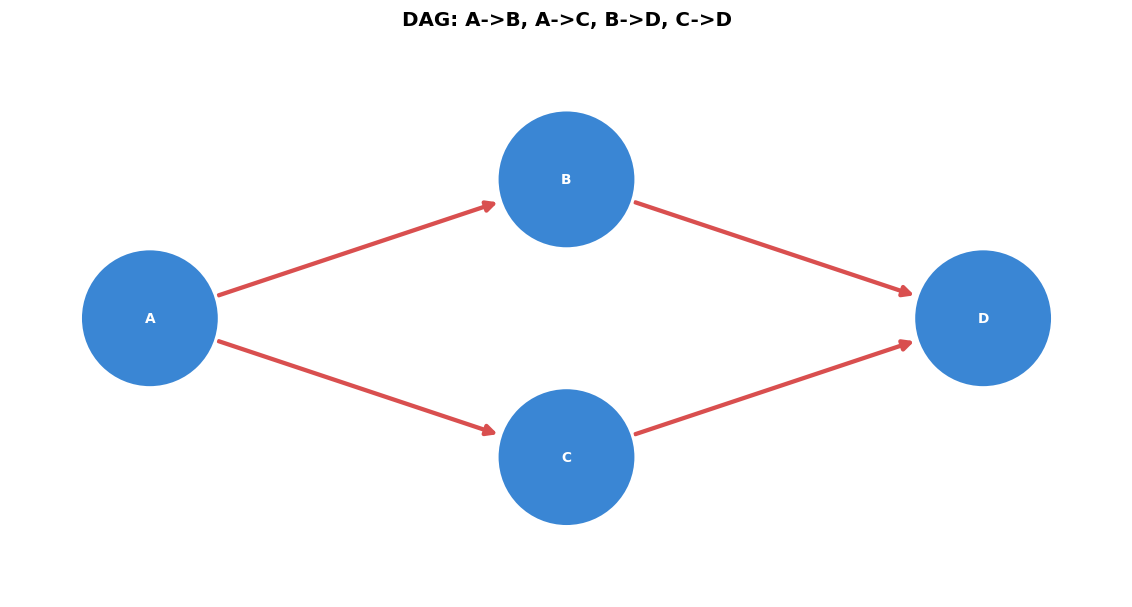

In [8]:
# ── Compare with DAG.all_paths() — same result ────────────────────────
dag = DAG(edges=[('A','B'),('A','C'),('B','D'),('C','D')])
print('DAG.all_paths A->D:', dag.all_paths('A','D'))

show_dag(dag,
         title='DAG: A->B, A->C, B->D, C->D',
         hi_edges=[('A','B'),('A','C'),('B','D'),('C','D')])

---
## Pattern 4 — Bottom-up computation: `Tree.height()`

Some recursive methods *return a value*.  
The crucial difference: **you compute the answer on the way back up**, not down.

```python
def height(node):
    children = tree.children(node)
    if not children:
        return 0                         # base case: leaf has height 0
    child_heights = [height(c) for c in children]
    return 1 + max(child_heights)        # combine results from children
```

The recursion goes all the way to the leaves **first**,  
then the values bubble up: leaf → parent → grandparent → … → root.

This is called **post-order** evaluation — leaves are evaluated before parents.

In [9]:
# ── Traced height(): watch values bubble up from leaves ───────────────
def traced_height(tree, node, depth=0):
    indent = '  ' * depth
    children = tree.children(node)
    print(f'{indent}height({node!r}): children = {children}')

    if not children:
        print(f'{indent}  -> leaf node, return 0')
        return 0

    child_h = []
    for c in children:
        h = traced_height(tree, c, depth + 1)
        child_h.append(h)

    result = 1 + max(child_h)
    print(f'{indent}  -> 1 + max({child_h}) = {result}')
    return result

#         root
#        /    \
#       A      B
#      / \
#     C   D
t = Tree(root='root', edges=[('root','A'),('root','B'),('A','C'),('A','D')])
print('Tree:  root -> A,B   A -> C,D')
print()
h = traced_height(t, 'root')
print()
print('height() =', h, '  (verified:', t.height(), ')')

Tree:  root -> A,B   A -> C,D

height('root'): children = ['A', 'B']
  height('A'): children = ['C', 'D']
    height('C'): children = []
      -> leaf node, return 0
    height('D'): children = []
      -> leaf node, return 0
    -> 1 + max([0, 0]) = 1
  height('B'): children = []
    -> leaf node, return 0
  -> 1 + max([1, 0]) = 2

height() = 2   (verified: 2 )


---
## Pre-order vs post-order: WHEN you process the node

The only difference between pre-order and post-order is  
**whether you add the node before or after the recursive calls**.

```python
def pre_order(node):          def post_order(node):
    result.append(node)           for child in children(node):
    for child in children(node):      post_order(child)
        pre_order(child)          result.append(node)   # AFTER
```

Pre-order = root first (**top-down**): good for printing hierarchy  
Post-order = leaves first (**bottom-up**): good for evaluating expressions, deleting trees

This mirrors the difference between a **boss giving orders** (pre)  
and a **worker reporting results** (post).

In [10]:
# ── Pre vs Post order on the same tree ───────────────────────────────
#
#         root
#        /    \
#       A      B
#      / \      \
#     C   D      E

t2 = Tree(root='root', edges=[
    ('root','A'),('root','B'),
    ('A','C'),('A','D'),('B','E')
])

pre  = t2.pre_order()
post = t2.post_order()

print('Tree structure (root -> A,B)  (A -> C,D)  (B -> E)')
print()
print('pre_order()  (root first, top-down)  :', pre)
print('  -> as if reading the tree LEFT to RIGHT, PARENT before CHILDREN')
print()
print('post_order() (leaves first, bottom-up):', post)
print('  -> as if computing a value BOTTOM UP (leaves contribute before parent)')

# Show which comes first: parent or children
print()
print('Depth of each node:')
for node in t2.nodes():
    print(f'  {node}: depth={t2.depth(node)}')

Tree structure (root -> A,B)  (A -> C,D)  (B -> E)

pre_order()  (root first, top-down)  : ['root', 'A', 'C', 'D', 'B', 'E']
  -> as if reading the tree LEFT to RIGHT, PARENT before CHILDREN

post_order() (leaves first, bottom-up): ['C', 'D', 'A', 'E', 'B', 'root']
  -> as if computing a value BOTTOM UP (leaves contribute before parent)

Depth of each node:
  A: depth=1
  B: depth=1
  C: depth=2
  D: depth=2
  E: depth=2
  root: depth=0


---
## DAG recursion: `descendants()` and `ancestors()`

Both are simple DFS spreading — the difference is *which adjacency dict* is used.

```python
def descendants(node):         def ancestors(node):
    visited = set()                visited = set()
    def dfs(u):                    def dfs(u):
        for v in FORWARD[u]:           for v in REVERSE[u]:   # ← only difference
            if v not in visited:           if v not in visited:
                visited.add(v)                 visited.add(v)
                dfs(v)                         dfs(v)
    dfs(node)                      dfs(node)
    return visited                 return visited
```

`descendants` follows arrows **forward** (where can I go FROM here?).  
`ancestors` follows arrows **backward** via `_reverse_adj` (who can reach me?).

This is useful for: *"if I change this module, what do I need to retest?"*

Build dependency DAG
Edge X->Y means: X directly depends on Y

descendants(app) = everything app depends on (transitively):
  ['api', 'base', 'db', 'ui', 'utils']

ancestors(utils) = everything that (transitively) depends on utils:
  ['api', 'app', 'ui']

If utils changes -> must retest: ['api', 'app', 'ui']


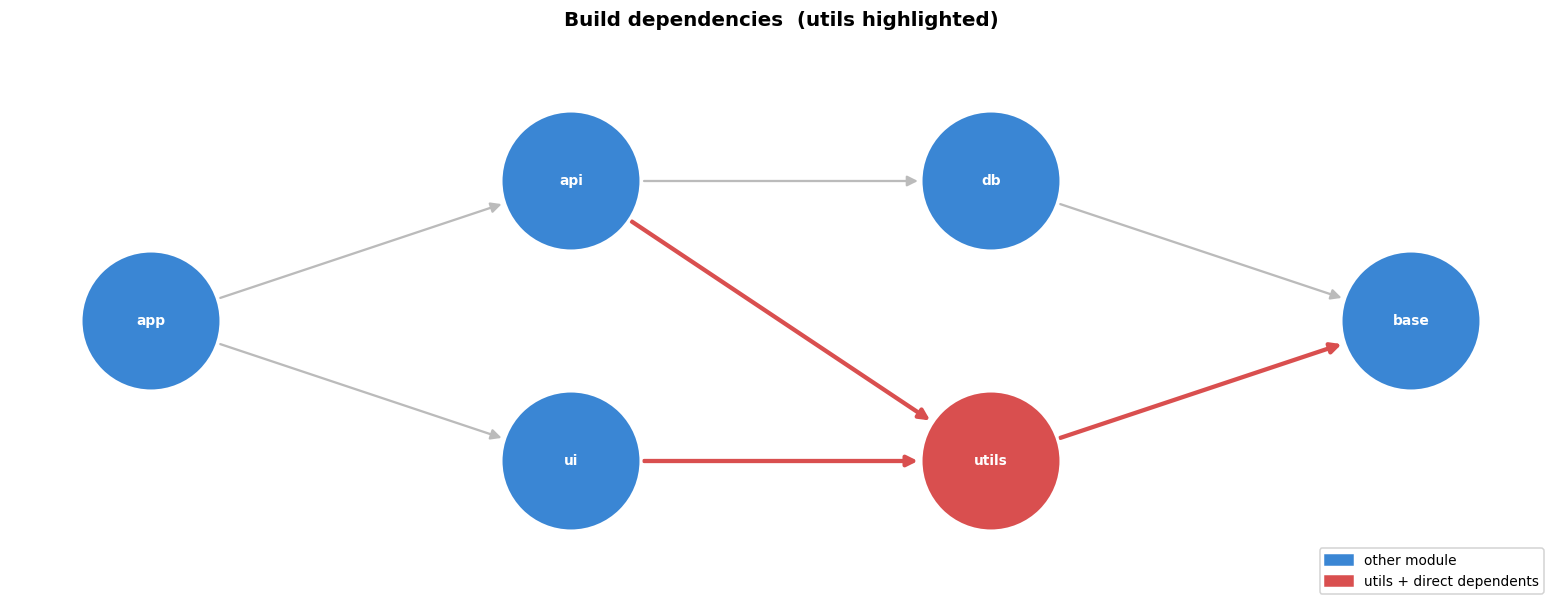

In [11]:
# ── descendants and ancestors on a build dependency DAG ──────────────
build = DAG(edges=[
    ('app',  'ui'),
    ('app',  'api'),
    ('ui',   'utils'),
    ('api',  'utils'),
    ('api',  'db'),
    ('utils','base'),
    ('db',   'base'),
])

print('Build dependency DAG')
print('Edge X->Y means: X directly depends on Y')
print()
print('descendants(app) = everything app depends on (transitively):')
print(' ', build.descendants('app'))
print()
print('ancestors(utils) = everything that (transitively) depends on utils:')
print(' ', build.ancestors('utils'))
print()
print('If utils changes -> must retest:', build.ancestors('utils'))

show_dag(build,
         title='Build dependencies  (utils highlighted)',
         hi_nodes=['utils'],
         hi_edges=[(s,d) for s,d in build.edges() if d=='utils' or s=='utils'],
         legend=[('#3A86D4','other module'), ('#D94F4F','utils + direct dependents')])

---
## Summary — three DFS patterns, countless algorithms

Every recursive graph algorithm in this library is one of:

### Pattern 1 — Spreading (marking)
```
visit(u):  mark u as seen
           for each unvisited neighbour v: visit(v)
```
→ `is_connected`, `connected_components`, `descendants`, `ancestors`

### Pattern 2 — State tracking  
```
visit(u):  set state[u] = ACTIVE
           for each neighbour v: check state[v], maybe recurse
           set state[u] = DONE
```
→ `has_cycle` (WHITE/GRAY/BLACK), `strongly_connected_components`

### Pattern 3 — Backtracking (explore & undo)
```
visit(u, path):  extend path with u
                 for each unvisited neighbour v: visit(v, path)
                 UNDO: remove u from path  ← the key step
```
→ `all_paths`, `minimum_dominating_sets`, `tsp`

### Pattern 4 — Bottom-up value (return on the way back)
```
value(u):  child_values = [value(c) for c in children(u)]
           return combine(child_values)   ← computed AFTER recursing
```
→ `height`, `depth`, `post_order`

---

**The key insight**: recursion on a graph is just *letting the call stack*  
*mirror the structure of the graph itself*.  
Each stack frame corresponds to one node; returning from it = stepping back along one edge.